In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/dataset/fault_times.json
/kaggle/input/dataset/calibration_only_params.json
/kaggle/input/dataset/synthetic_ground_truth.csv
/kaggle/input/dataset/adjacency.npy
/kaggle/input/dataset/df_faulty_adv.csv


A fault state is defined as a persistent, latent regime in which a node’s behavior deviates from normal system dynamics and cannot be explained by short-term temporal fluctuations or measurement noise.

Option B failed because, although supervised classification improved fault ranking, it treated faults as independent binary events, leading to unstable predictions and unreliable thresholding under strong class overlap.

The missing signal is temporal regime consistency: Option B lacks a mechanism to model fault onset, persistence, and recovery as a continuous state rather than isolated detections.

Option C introduces an explicit latent fault state, learned through temporal modeling, that enforces consistency across time and captures fault dynamics as a regime change.

This fault state is then used to condition downstream prediction, enabling the model to distinguish between normal and faulty regimes while preserving normal-operation performance.

In [2]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import json

# Load base data
df_faulty = pd.read_csv("/kaggle/input/dataset/df_faulty_adv.csv")

with open("/kaggle/input/dataset/fault_times.json") as f:
    fault_times = set(json.load(f))

FAULTY_SENDER = 2


In [3]:
def build_fault_labels(df, fault_times, faulty_sender):
    df = df.copy()
    df["fault_label"] = (
        (df.sender == faulty_sender) &
        (df.time_index.isin(fault_times))
    ).astype(int)
    return df

df = build_fault_labels(df_faulty, fault_times, FAULTY_SENDER)


In [4]:
df["theta_calib"] = df["value"]

# Probe disagreement
probe_diff = (
    df.pivot_table(
        index=["time_index", "sender"],
        columns="probe",
        values="value"
    )
    .dropna()
)

probe_diff["probe_disagreement"] = (
    probe_diff.iloc[:, 0] - probe_diff.iloc[:, 1]
).abs()

probe_diff = probe_diff.reset_index()[
    ["time_index", "sender", "probe_disagreement"]
]

df = df.merge(
    probe_diff,
    on=["time_index", "sender"],
    how="left"
)

# Temporal delta
df = df.sort_values(["sender", "time_index"])
df["delta_theta"] = (
    df.groupby("sender")["theta_calib"]
      .diff()
      .fillna(0.0)
)

FEATURE_COLUMNS = [
    "theta_calib",
    "probe_disagreement",
    "delta_theta"
]

df[FEATURE_COLUMNS] = df[FEATURE_COLUMNS].fillna(0.0)


In [5]:
def build_sequences(
    df,
    feature_cols,
    label_col,
    window_size=25,
    stride=1
):
    """
    Returns:
        X: (B, T, F)
        Y: (B, T)
    """
    X, Y = [], []

    for sender in df.sender.unique():
        df_node = (
            df[df.sender == sender]
            .sort_values("time_index")
            .reset_index(drop=True)
        )

        features = df_node[feature_cols].values
        labels = df_node[label_col].values

        for start in range(0, len(df_node) - window_size + 1, stride):
            end = start + window_size

            X.append(features[start:end])
            Y.append(labels[start:end])

    return (
        torch.from_numpy(np.array(X)).float(),
        torch.from_numpy(np.array(Y)).float()
    )



In [6]:
WINDOW_SIZE = 25   # recommended starting point

X, Y = build_sequences(
    df,
    FEATURE_COLUMNS,
    "fault_label",
    window_size=WINDOW_SIZE
)

print("X shape:", X.shape)  # (B, T, F)
print("Y shape:", Y.shape)  # (B, T)


X shape: torch.Size([1109, 25, 3])
Y shape: torch.Size([1109, 25])


In [7]:
class FaultSequenceDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]


dataset = FaultSequenceDataset(X, Y)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    drop_last=True
)


In [8]:
assert X.ndim == 3
assert Y.ndim == 2
assert X.shape[0] == Y.shape[0]
assert X.shape[1] == Y.shape[1]
assert X.shape[2] == len(FEATURE_COLUMNS)


In [9]:
print("Fault ratio:", Y.mean().item())


Fault ratio: 0.01803426444530487


In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FaultStateGRU(nn.Module):
    """
    GRU-based latent fault state model.
    Outputs P(fault_t | history).
    """

    def __init__(
        self,
        input_dim: int,
        hidden_dim: int = 32,
        num_layers: int = 1,
        dropout: float = 0.0
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.fault_head = nn.Linear(hidden_dim, 1)

    def forward(self, x, h0=None):
        """
        x: Tensor of shape (B, T, F)
        h0: Optional initial hidden state

        returns:
            fault_logits: (B, T)
            fault_probs:  (B, T)
            hidden:       (B, T, H)
        """
        hidden, hT = self.gru(x, h0)          # (B, T, H)
        logits = self.fault_head(hidden)      # (B, T, 1)
        logits = logits.squeeze(-1)            # (B, T)

        probs = torch.sigmoid(logits)

        return logits, probs, hidden


In [11]:
def temporal_smoothness_loss(fault_probs):
    """
    Penalizes rapid fault ↔ normal oscillations.

    fault_probs: (B, T)
    """
    return torch.mean(torch.abs(fault_probs[:, 1:] - fault_probs[:, :-1]))


In [12]:
def fault_state_loss(
    logits,
    targets,
    smoothness_weight=0.1,
    pos_weight=10.0
):
    """
    logits:  (B, T)
    targets: (B, T) ∈ {0,1}
    """

    bce = F.binary_cross_entropy_with_logits(
        logits,
        targets,
        pos_weight=torch.tensor(pos_weight, device=logits.device)
    )

    probs = torch.sigmoid(logits)
    smooth = temporal_smoothness_loss(probs)

    return bce + smoothness_weight * smooth


In [13]:
def train_fault_state_model(
    model,
    dataloader,
    epochs=30,
    lr=1e-3,
    smoothness_weight=0.1,
    pos_weight=10.0,
    device="cuda" if torch.cuda.is_available() else "cpu"
):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        losses = []

        for x, y in dataloader:
            x = x.to(device)   # (B, T, F)
            y = y.to(device)   # (B, T)

            optimizer.zero_grad()

            logits, probs, _ = model(x)
            loss = fault_state_loss(
                logits,
                y,
                smoothness_weight=smoothness_weight,
                pos_weight=pos_weight
            )

            loss.backward()
            optimizer.step()

            losses.append(loss.item())

        print(
            f"Epoch {epoch:03d} | "
            f"Loss: {sum(losses)/len(losses):.4f}"
        )

    return model



In [14]:
from torch.utils.data import random_split

dataset = FaultSequenceDataset(X, Y)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_ds, val_ds = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)


In [15]:
model = FaultStateGRU(input_dim=len(FEATURE_COLUMNS))

# model = train_fault_state_model(
#     model,
#     train_loader,
#     epochs=40,
#     smoothness_weight=0.1,
#     pos_weight=10.0
# )
model = train_fault_state_model(
    model,
    train_loader,
    epochs=40,
    smoothness_weight=0.05,   # ↓ from 0.1
    pos_weight=20.0           # ↑ from 10
)



Epoch 000 | Loss: 0.8258
Epoch 001 | Loss: 0.7221
Epoch 002 | Loss: 0.6388
Epoch 003 | Loss: 0.5720
Epoch 004 | Loss: 0.4858
Epoch 005 | Loss: 0.4104
Epoch 006 | Loss: 0.3635
Epoch 007 | Loss: 0.3308
Epoch 008 | Loss: 0.2988
Epoch 009 | Loss: 0.2892
Epoch 010 | Loss: 0.2790
Epoch 011 | Loss: 0.2586
Epoch 012 | Loss: 0.2370
Epoch 013 | Loss: 0.2225
Epoch 014 | Loss: 0.2100
Epoch 015 | Loss: 0.2009
Epoch 016 | Loss: 0.1947
Epoch 017 | Loss: 0.1888
Epoch 018 | Loss: 0.1800
Epoch 019 | Loss: 0.1775
Epoch 020 | Loss: 0.1744
Epoch 021 | Loss: 0.1690
Epoch 022 | Loss: 0.1634
Epoch 023 | Loss: 0.1617
Epoch 024 | Loss: 0.1561
Epoch 025 | Loss: 0.1534
Epoch 026 | Loss: 0.1470
Epoch 027 | Loss: 0.1449
Epoch 028 | Loss: 0.1453
Epoch 029 | Loss: 0.1468
Epoch 030 | Loss: 0.1405
Epoch 031 | Loss: 0.1390
Epoch 032 | Loss: 0.1393
Epoch 033 | Loss: 0.1335
Epoch 034 | Loss: 0.1285
Epoch 035 | Loss: 0.1282
Epoch 036 | Loss: 0.1163
Epoch 037 | Loss: 0.1207
Epoch 038 | Loss: 0.1181
Epoch 039 | Loss: 0.1122


In [16]:
def collect_fault_probs(model, dataloader, device="cuda" if torch.cuda.is_available() else "cpu"):
    model.eval()
    all_probs, all_targets = [], []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            logits, probs, _ = model(x)

            all_probs.append(probs.cpu())
            all_targets.append(y)

    return (
        torch.cat(all_probs, dim=0),
        torch.cat(all_targets, dim=0)
    )

val_probs, val_targets = collect_fault_probs(model, val_loader)


In [17]:
temporal_variation = torch.mean(
    torch.abs(val_probs[:, 1:] - val_probs[:, :-1])
).item()

print("Temporal variation (lower is better):", temporal_variation)


Temporal variation (lower is better): 0.04227813333272934


In [18]:
def fault_persistence_score(probs, threshold=0.5):
    binary = (probs > threshold).float()
    return torch.mean(binary[:, 1:] * binary[:, :-1]).item()

print("Fault persistence:", fault_persistence_score(val_probs))


Fault persistence: 0.007695195265114307


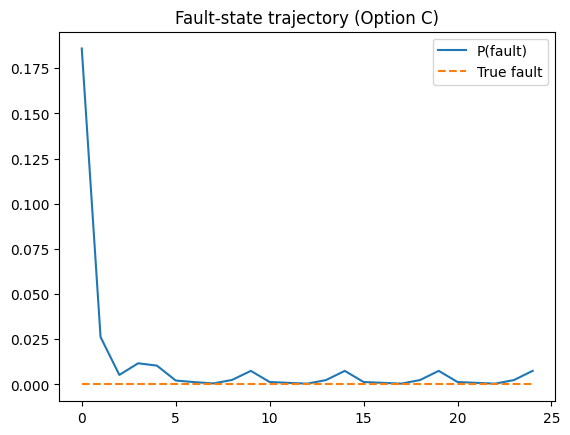

In [19]:
import matplotlib.pyplot as plt

idx = 0  # any validation sequence
plt.plot(val_probs[idx].numpy(), label="P(fault)")
plt.plot(val_targets[idx].numpy(), label="True fault", linestyle="--")
plt.legend()
plt.title("Fault-state trajectory (Option C)")
plt.show()


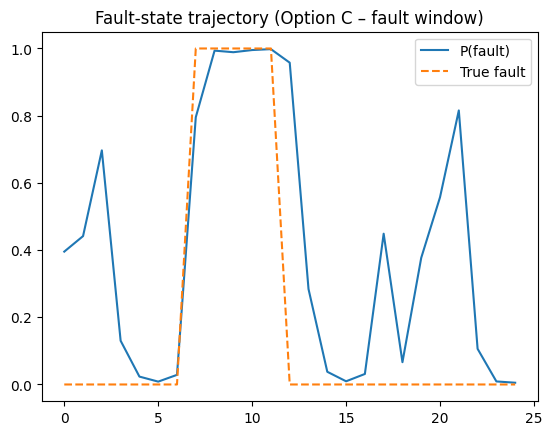

In [20]:
fault_seq_idx = torch.where(val_targets.sum(dim=1) > 0)[0][0].item()

plt.plot(val_probs[fault_seq_idx].numpy(), label="P(fault)")
plt.plot(val_targets[fault_seq_idx].numpy(), label="True fault", linestyle="--")
plt.legend()
plt.title("Fault-state trajectory (Option C – fault window)")
plt.show()


In [21]:
# Collect fault probabilities with indices
model.eval()

records = []
seq_len = WINDOW_SIZE

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(next(model.parameters()).device)
        logits, probs, _ = model(x)

        probs = probs.cpu().numpy()
        y = y.numpy()

        for b in range(probs.shape[0]):
            for t in range(seq_len):
                records.append({
                    "sequence_idx": b,
                    "t_in_window": t,
                    "p_fault": probs[b, t],
                    "true_fault": y[b, t]
                })

fault_prob_df = pd.DataFrame(records)
fault_prob_df.head()


,sequence_idx,t_in_window,p_fault,true_fault
0,0,0,0.185984,0.0
1,0,1,0.026269,0.0
2,0,2,0.005292,0.0
3,0,3,0.011733,0.0
4,0,4,0.010437,0.0


In [22]:
fault_prob_df["p_fault"].describe()


count    5550.000000
mean        0.049002
std         0.129962
min         0.000293
25%         0.001308
50%         0.003643
75%         0.018417
max         0.998051
Name: p_fault, dtype: float64

Option C – Stage 1 complete.
GRU learns a temporally consistent latent fault state.
Next step: condition prediction on p_fault.


In [23]:
model.eval()
p_fault_rows = []

with torch.no_grad():
    for sender in df.sender.unique():
        df_node = (
            df[df.sender == sender]
            .sort_values("time_index")
            .reset_index(drop=True)
        )

        if len(df_node) < WINDOW_SIZE:
            continue

        X_node = []

        for i in range(len(df_node) - WINDOW_SIZE + 1):
            X_node.append(
                df_node.iloc[i:i+WINDOW_SIZE][FEATURE_COLUMNS].values
            )

        X_node = torch.tensor(X_node, dtype=torch.float32).to(
            next(model.parameters()).device
        )

        _, probs, _ = model(X_node)
        probs = probs.cpu().numpy()

        for i, p in enumerate(probs[:, -1]):
            p_fault_rows.append({
                "sender": sender,
                "time_index": df_node.loc[i + WINDOW_SIZE - 1, "time_index"],
                "p_fault": float(p)
            })


/tmp/ipykernel_288/4134232468.py:22: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  X_node = torch.tensor(X_node, dtype=torch.float32).to(


In [24]:
p_fault_df = pd.DataFrame(p_fault_rows)

df_pred = df.merge(
    p_fault_df,
    on=["sender", "time_index"],
    how="left"
)

df_pred["p_fault"] = (
    df_pred
    .sort_values(["sender", "time_index"])
    .groupby("sender")["p_fault"]
    .ffill()
    .fillna(0.0)
)

assert df_pred["fault_label"].sum() > 0


In [25]:
# =========================
# MERGE CLEAN GROUND TRUTH
# =========================

df_gt = pd.read_csv("/kaggle/input/dataset/synthetic_ground_truth.csv")

# keep only temperature ground truth
df_gt = (
    df_gt[df_gt["modality"] == "temperature"]
    .sort_values(["sender", "timestamp"])
    .reset_index(drop=True)
)

# recreate aligned time_index
df_gt["time_index"] = df_gt.groupby("sender").cumcount()

# merge clean target into prediction dataframe
df_pred = df_pred.merge(
    df_gt[["sender", "time_index", "value"]],
    on=["sender", "time_index"],
    how="left",
    suffixes=("", "_gt")
)

df_pred = df_pred.rename(columns={"value_gt": "value_y"})



In [26]:
print("Fault rows:", df_pred["fault_label"].sum())
print("GT available rows:", df_pred["value_y"].notna().sum())


Fault rows: 100
GT available rows: 1400


In [27]:
valid_mask = df_pred["value_y"].notna()
fault_mask = (df_pred["fault_label"] == 1) & valid_mask


In [28]:
BASE_FEATURES = [
    "theta_calib",
    "probe_disagreement",
    "delta_theta"
]
TARGET_COL="value_y"
FAULT_AWARE_FEATURES = BASE_FEATURES + ["p_fault"]

# Keep only rows where ground truth exists
train_mask = df_pred[TARGET_COL].notna()

X_base  = df_pred.loc[train_mask, BASE_FEATURES].values
X_fault = df_pred.loc[train_mask, FAULT_AWARE_FEATURES].values
y       = df_pred.loc[train_mask, TARGET_COL].values



In [29]:
from sklearn.linear_model import Ridge

X_base  = df_pred[BASE_FEATURES].values
X_fault = df_pred[FAULT_AWARE_FEATURES].values
y       = df_pred[TARGET_COL].values

model_base = Ridge(alpha=1.0).fit(X_base, y)
model_fault = Ridge(alpha=1.0).fit(X_fault, y)

y_pred_base  = model_base.predict(X_base)
y_pred_fault = model_fault.predict(X_fault)

fault_mask = (
    (df_pred["fault_label"] == 1) &
    train_mask
)

print("Fault rows with GT:", fault_mask.sum())
assert fault_mask.sum() > 0



ValueError: Input y contains NaN.

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

def rmse(a, b):
    return np.sqrt(mean_squared_error(a, b))

results = {
    "baseline_rmse_all": rmse(y, y_pred_base),
    "faultaware_rmse_all": rmse(y, y_pred_fault),
    "baseline_rmse_fault": rmse(
        df_pred.loc[fault_mask, TARGET_COL],
        y_pred_base[fault_mask[train_mask]]
    ),
    "faultaware_rmse_fault": rmse(
        df_pred.loc[fault_mask, TARGET_COL],
        y_pred_fault[fault_mask[train_mask]]
    ),
}

results
